# BrainInsight AI
## Notebook 01: Exploratory Data Analysis (EDA)

### Objectives
- Explore the Brain MRI dataset
- Analyze class distribution
- Visualize sample images
- Inspect image properties
- Detect corrupted and duplicate images
- Prepare insights for preprocessing

> **Dataset Structure**
```
dataset/
    Training/
        glioma/
        meningioma/
        pituitary/
        notumor/
    Testing/
        glioma/
        meningioma/
        pituitary/
        notumor/
```


In [1]:
# ==========================
# Required Libraries
# ==========================
import os
import cv2
import hashlib
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
random.seed(42)

PROJECT_ROOT = Path("..")
DATASET_DIR = PROJECT_ROOT / "dataset"
TRAIN_DIR = DATASET_DIR / "Training"
TEST_DIR = DATASET_DIR / "Testing"

print("Training Folder:", TRAIN_DIR)
print("Testing Folder :", TEST_DIR)


Training Folder: ..\dataset\Training
Testing Folder : ..\dataset\Testing


## Utility Functions

In [2]:
def load_dataset(split_path, split_name):
    records = []
    if not split_path.exists():
        print(f"Warning: {split_path} not found")
        return records

    for cls in sorted(os.listdir(split_path)):
        class_dir = split_path / cls
        if not class_dir.is_dir():
            continue

        for img in class_dir.iterdir():
            if img.suffix.lower() in ['.jpg','.jpeg','.png','.bmp','.tif','.tiff']:
                records.append({
                    "image_path": str(img),
                    "class": cls,
                    "split": split_name
                })
    return records

def image_hash(path):
    try:
        with open(path,"rb") as f:
            return hashlib.md5(f.read()).hexdigest()
    except:
        return None


## Load Dataset

In [3]:
train_data = load_dataset(TRAIN_DIR,"Training")
test_data = load_dataset(TEST_DIR,"Testing")

df = pd.DataFrame(train_data + test_data)

print("Total Images:", len(df))
display(df.head())


Total Images: 7200


,image_path,class,split
0,..\dataset\Training\glioma\Tr-gl_1.jpg,glioma,Training
1,..\dataset\Training\glioma\Tr-gl_10.jpg,glioma,Training
2,..\dataset\Training\glioma\Tr-gl_100.jpg,glioma,Training
3,..\dataset\Training\glioma\Tr-gl_1000.jpg,glioma,Training
4,..\dataset\Training\glioma\Tr-gl_1001.jpg,glioma,Training


## Dataset Statistics

In [4]:
print("\nClass Distribution")
display(df["class"].value_counts())

print("\nSplit Distribution")
display(df["split"].value_counts())

summary = pd.crosstab(df["class"],df["split"])
display(summary)



Class Distribution


class
glioma        1800
meningioma    1800
notumor       1800
pituitary     1800
Name: count, dtype: int64


Split Distribution


split
Training    5600
Testing     1600
Name: count, dtype: int64

split,Testing,Training
class,,
glioma,400,1400
meningioma,400,1400
notumor,400,1400
pituitary,400,1400


## Class Distribution

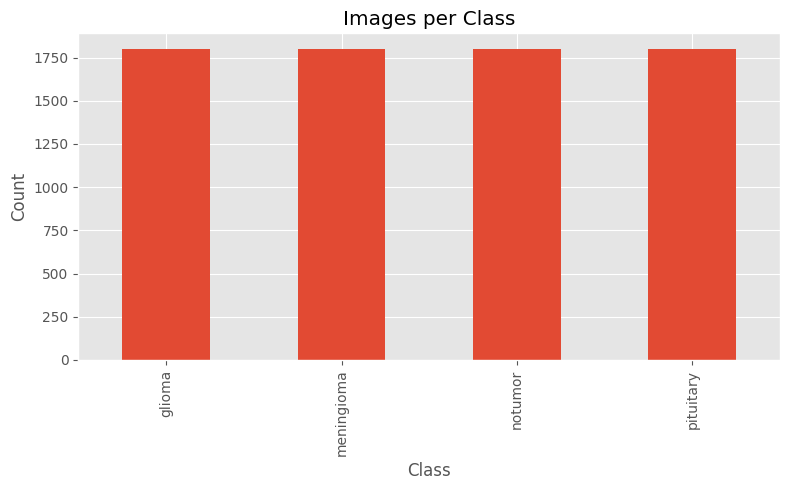

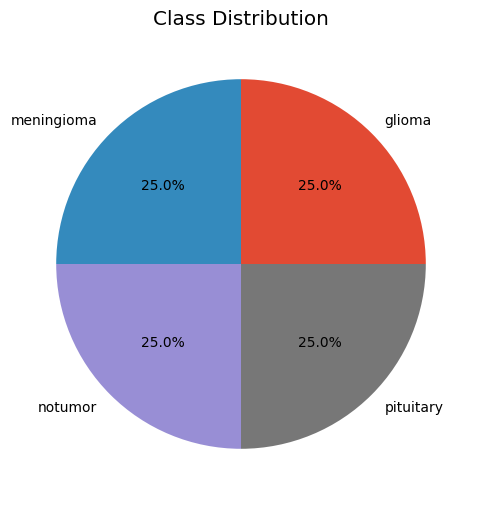

In [5]:
plt.figure(figsize=(8,5))
df["class"].value_counts().plot(kind="bar")
plt.title("Images per Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
df["class"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.ylabel("")
plt.title("Class Distribution")
plt.show()


## Train vs Test Distribution

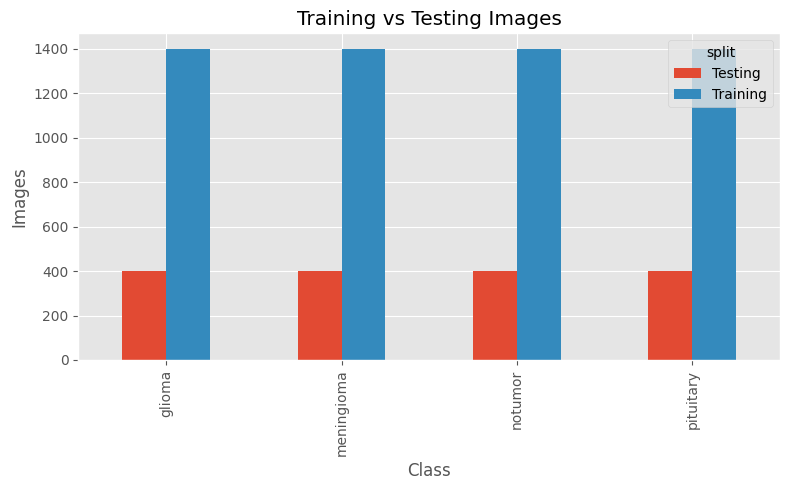

In [6]:
summary.plot(kind="bar",figsize=(8,5))
plt.title("Training vs Testing Images")
plt.xlabel("Class")
plt.ylabel("Images")
plt.tight_layout()
plt.show()


## Display Sample Images

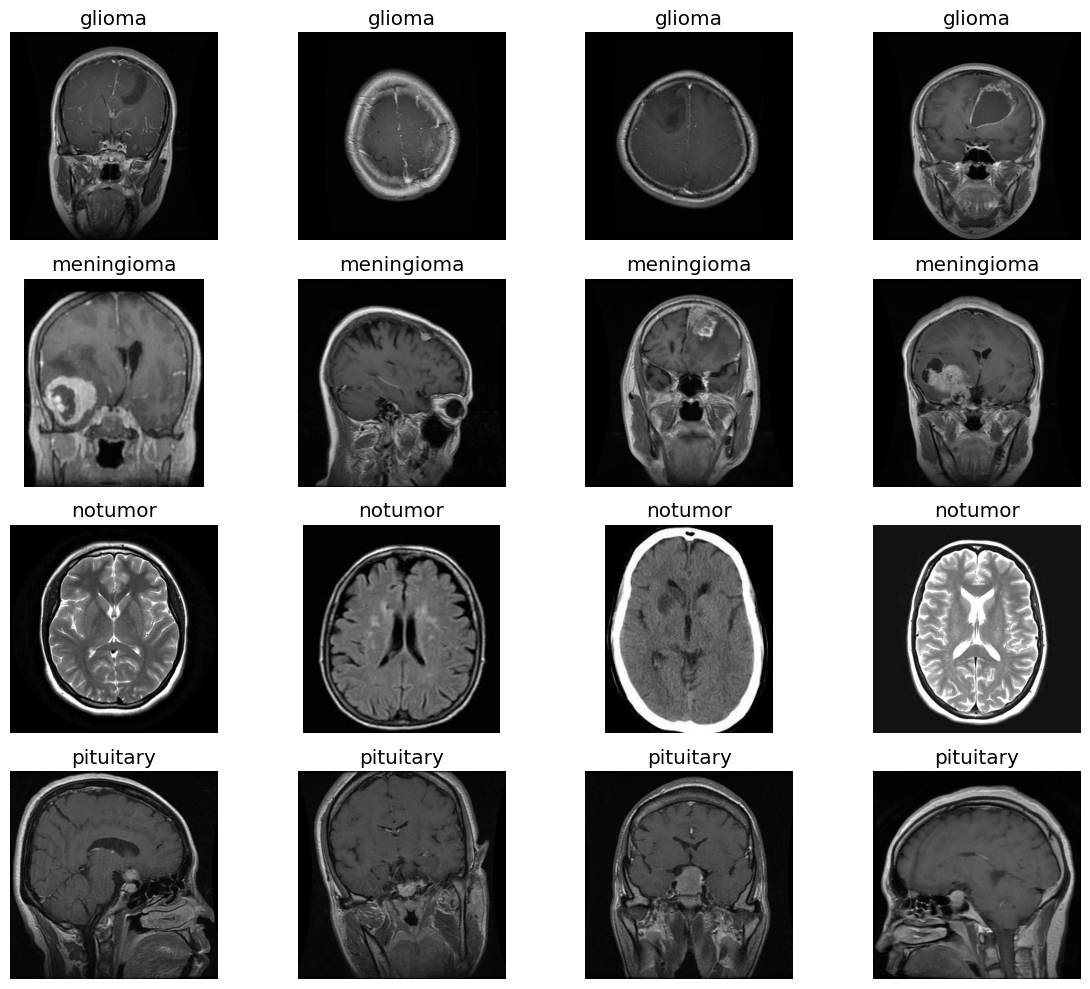

In [7]:
classes = sorted(df["class"].unique())

fig,axes = plt.subplots(len(classes),4,figsize=(12,10))

for r,cls in enumerate(classes):
    imgs = df[df["class"]==cls].sample(min(4,len(df[df["class"]==cls])),random_state=42)

    for c,(_,row) in enumerate(imgs.iterrows()):
        img = cv2.imread(row["image_path"])
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        axes[r,c].imshow(img)
        axes[r,c].set_title(cls)
        axes[r,c].axis("off")

plt.tight_layout()
plt.show()


## Image Property Analysis

In [8]:
properties=[]

for path in df["image_path"]:
    img=cv2.imread(path)

    if img is None:
        continue

    h,w,ch=img.shape

    gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    properties.append({
        "height":h,
        "width":w,
        "channels":ch,
        "aspect_ratio":round(w/h,2),
        "mean_intensity":gray.mean()
    })

prop_df=pd.DataFrame(properties)

display(prop_df.describe())


,height,width,channels,aspect_ratio,mean_intensity
count,7200.000000,7200.000000,7200.0,7200.000000,7200.000000
mean,456.899167,453.302917,3.0,0.989683,47.558191
std,124.402496,130.048964,0.0,0.091832,17.836066
min,167.000000,150.000000,3.0,0.640000,14.944813
25%,449.000000,442.000000,3.0,1.000000,35.310922
50%,512.000000,512.000000,3.0,1.000000,44.291139
75%,512.000000,512.000000,3.0,1.000000,54.517842
max,1446.000000,1375.000000,3.0,1.790000,137.764303


## Image Size Distribution

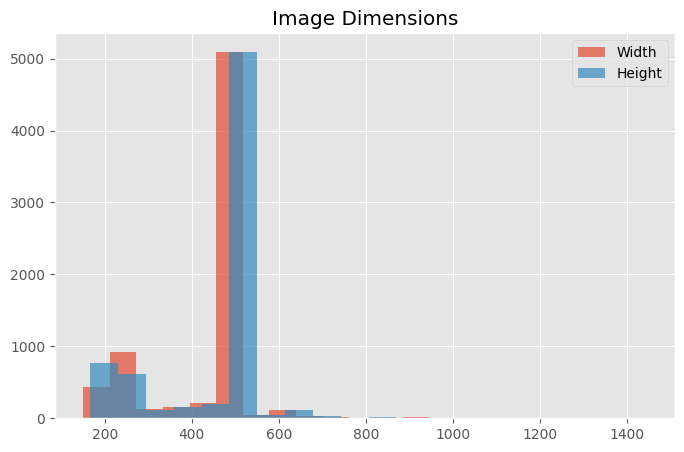

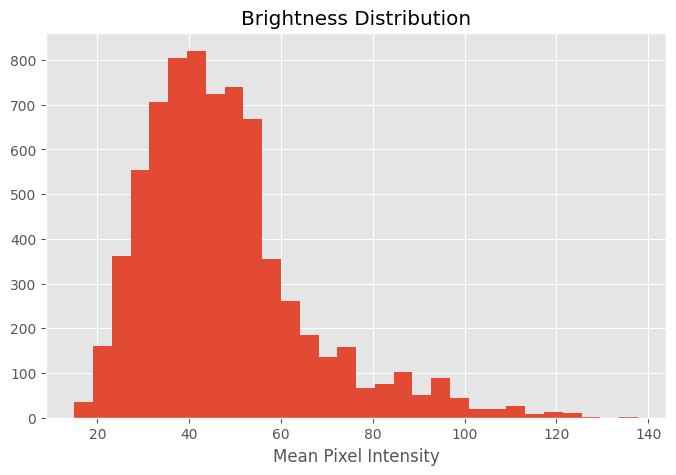

In [9]:
plt.figure(figsize=(8,5))
plt.hist(prop_df["width"],bins=20,alpha=0.7,label="Width")
plt.hist(prop_df["height"],bins=20,alpha=0.7,label="Height")
plt.legend()
plt.title("Image Dimensions")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(prop_df["mean_intensity"],bins=30)
plt.title("Brightness Distribution")
plt.xlabel("Mean Pixel Intensity")
plt.show()


## Corrupted Image Detection

In [10]:
corrupted=[]

for path in df["image_path"]:
    img=cv2.imread(path)
    if img is None:
        corrupted.append(path)

print("Corrupted Images:",len(corrupted))

if corrupted:
    display(pd.DataFrame(corrupted,columns=["Image"]))


Corrupted Images: 0


## Duplicate Detection

In [11]:
hash_dict={}
duplicates=[]

for path in df["image_path"]:
    h=image_hash(path)
    if h is None:
        continue

    if h in hash_dict:
        duplicates.append((hash_dict[h],path))
    else:
        hash_dict[h]=path

print("Duplicate Images:",len(duplicates))

if duplicates:
    display(pd.DataFrame(duplicates,columns=["Original","Duplicate"]))


Duplicate Images: 187


,Original,Duplicate
0,..\dataset\Training\meningioma\Tr-aug-me_90.jpg,..\dataset\Training\meningioma\Tr-me_1242.jpg
1,..\dataset\Training\meningioma\Tr-aug-me_98.jpg,..\dataset\Training\meningioma\Tr-me_1274.jpg
2,..\dataset\Training\meningioma\Tr-aug-me_95.jpg,..\dataset\Training\meningioma\Tr-me_1295.jpg
3,..\dataset\Training\meningioma\Tr-me_1094.jpg,..\dataset\Training\meningioma\Tr-me_219.jpg
4,..\dataset\Training\meningioma\Tr-aug-me_91.jpg,..\dataset\Training\meningioma\Tr-me_245.jpg
...,...,...
182,..\dataset\Testing\glioma\Te-gl_32.jpg,..\dataset\Testing\glioma\Te-gl_389.jpg
183,..\dataset\Testing\glioma\Te-gl_144.jpg,..\dataset\Testing\glioma\Te-gl_59.jpg
184,..\dataset\Testing\glioma\Te-gl_143.jpg,..\dataset\Testing\glioma\Te-gl_72.jpg
185,..\dataset\Testing\meningioma\Te-me_179.jpg,..\dataset\Testing\meningioma\Te-me_198.jpg


## Observations

- Checked dataset structure.
- Verified class distribution.
- Visualized representative MRI images.
- Analyzed image dimensions and brightness.
- Identified corrupted and duplicate images (if any).
- Dataset is ready for preprocessing.


# Conclusion

EDA provides a clear understanding of the dataset before feature engineering and model training. Detecting issues such as class imbalance, corrupted files, and duplicate images early improves the reliability of the complete machine learning pipeline.


# Interview Notes

**Q1. Why perform EDA?**  
To understand data quality, distribution, and potential issues before preprocessing.

**Q2. Why check for corrupted images?**  
They can crash the preprocessing pipeline and reduce model quality.

**Q3. Why inspect class distribution?**  
To detect imbalance that may bias the classifier.

**Q4. Why analyze image dimensions?**  
To choose a consistent resize strategy for preprocessing.

**Q5. What is the output of this notebook?**  
A validated dataset with insights that guide preprocessing and feature extraction.
